Task 5: Sales Data Analysis (Superstore)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('superstore.csv', encoding='latin1')
def _parse_mixed_date(s):
    for fmt in ('%m/%d/%Y', '%d/%m/%Y', '%m/%d/%y', '%d/%m/%y'):
        try:
            return pd.to_datetime(s, format=fmt)
        except (ValueError, TypeError):
            continue
    # fallback to pandas inference (dayfirst True helps with d/m/Y cases)
    return pd.to_datetime(s, dayfirst=True, errors='coerce')

df['Order Date'] = df['Order_Date'].apply(_parse_mixed_date)
df['Month'] = df['Order Date'].dt.to_period('M')
print(df.columns)
print(df.head())

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales', 'Order Date', 'Month'],
      dtype='object')
   Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode Customer_ID  \
0       1  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688   12/6/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer_Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderso

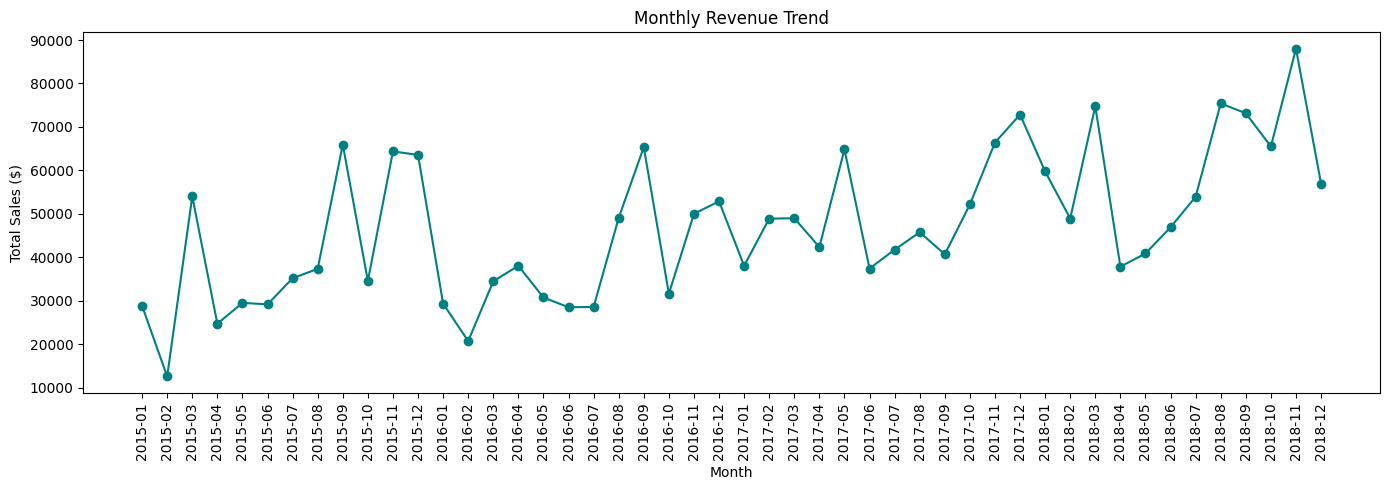

In [3]:
monthly = df.groupby('Month')['Sales'].sum().reset_index()
monthly['Month'] = monthly['Month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly['Month'], monthly['Sales'], marker='o', color='teal')
plt.xticks(rotation=90)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('monthly_revenue.png')
plt.show()

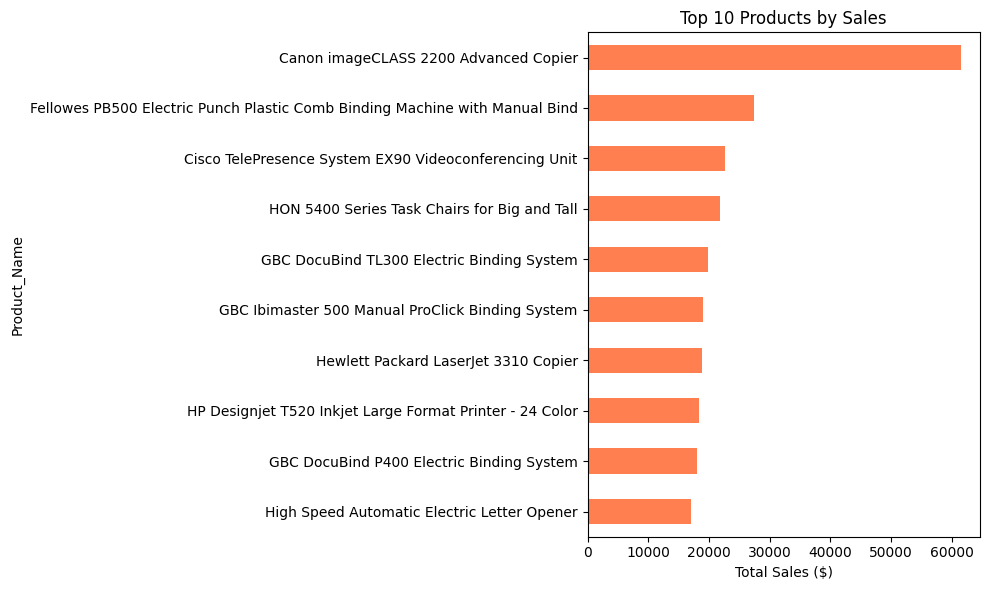

In [4]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products.plot(kind='barh', color='coral')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

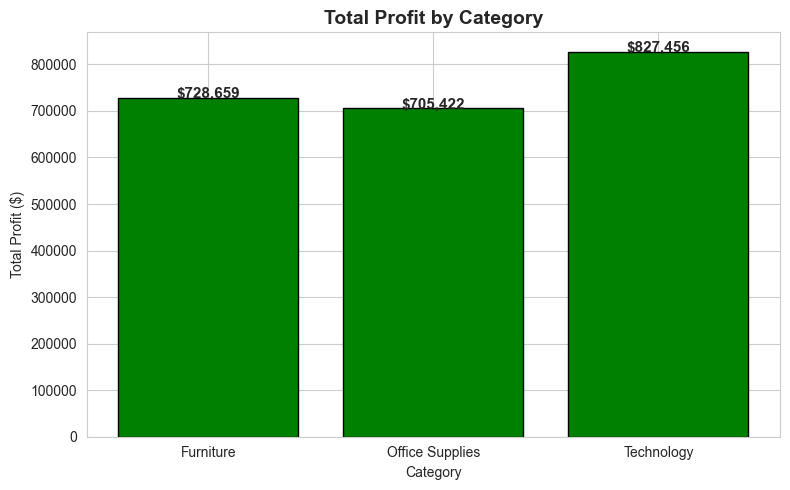

✅ profit_by_category.png saved


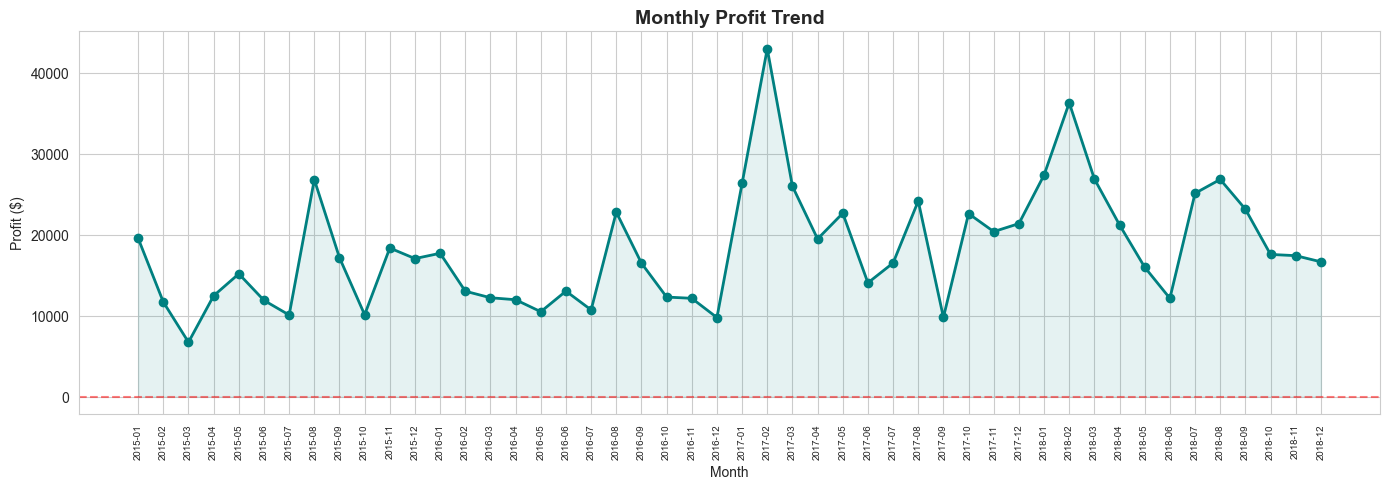

✅ monthly_profit_trend.png saved


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create plots folder if it doesn't exist
os.makedirs('plots', exist_ok=True)

# Load dataset
df = pd.read_csv('superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Month'] = df['Order Date'].dt.to_period('M')

sns.set_style("whitegrid")

# ── Plot 1: Profit by Category ────────────────────────────────
plt.figure(figsize=(8, 5))
if 'Profit' not in df.columns:
    df['Profit'] = df['Sales']

profit_cat = df.groupby('Category')['Profit'].sum().reset_index()
colors = ['green' if x > 0 else 'red' for x in profit_cat['Profit']]

bars = plt.bar(profit_cat['Category'], profit_cat['Profit'], color=colors, edgecolor='black')

# Add value labels on bars
for bar, val in zip(bars, profit_cat['Profit']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'${val:,.0f}',
             ha='center', fontsize=11, fontweight='bold')

plt.title('Total Profit by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('plots/profit_by_category.png', dpi=150)
plt.show()
print("✅ profit_by_category.png saved")

# ── Plot 2: Monthly Profit Trend ──────────────────────────────
plt.figure(figsize=(14, 5))
monthly_profit = df.groupby('Month')['Profit'].sum().reset_index()
monthly_profit['Month'] = monthly_profit['Month'].astype(str)

plt.plot(monthly_profit['Month'], monthly_profit['Profit'],
         marker='o', color='teal', linewidth=2)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.fill_between(range(len(monthly_profit)),
                 monthly_profit['Profit'],
                 alpha=0.1, color='teal')
plt.xticks(range(len(monthly_profit)),
           monthly_profit['Month'], rotation=90, fontsize=7)
plt.title('Monthly Profit Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.savefig('plots/monthly_profit_trend.png', dpi=150)
plt.show()
print("✅ monthly_profit_trend.png saved")